<a href="https://colab.research.google.com/github/23070075-creator/NNDL-Lab/blob/main/NNDL_Practical_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully.
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST dataset loaded successfully.
Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


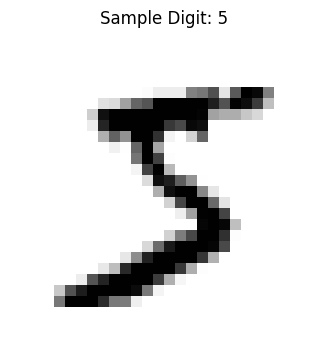

Pixel values normalized successfully.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9190 - loss: 0.2804 - val_accuracy: 0.9578 - val_loss: 0.1498
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9624 - loss: 0.1280 - val_accuracy: 0.9652 - val_loss: 0.1169
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9745 - loss: 0.0876 - val_accuracy: 0.9710 - val_loss: 0.0959
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9805 - loss: 0.0643 - val_accuracy: 0.9726 - val_loss: 0.0888
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9853 - loss: 0.0492 - val_accuracy: 0.9745 - val_loss: 0.0865
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9888 - loss: 0.0383 - val_accuracy: 0.9751 - val_loss: 0.0844
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9912 - loss: 0.0301 - val_accuracy: 0.9724 - val_loss: 0.0943
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9925 - loss: 0.0248 -

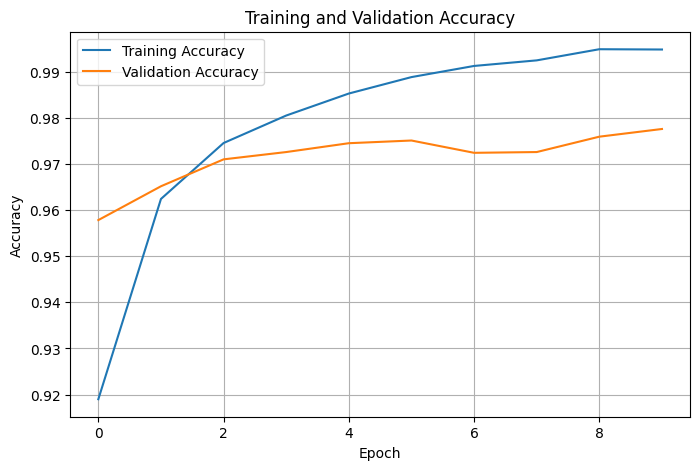

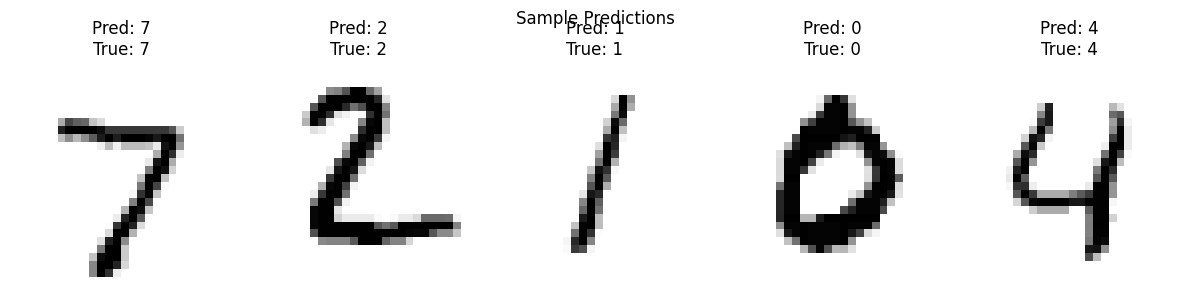

Predictions displayed successfully.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

print("Libraries imported successfully.")

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("MNIST dataset loaded successfully.")
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

plt.figure(figsize=(4, 4))
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.title(f"Sample Digit: {y_train[0]}")
plt.axis("off")
plt.show()

x_train_normalized = x_train.astype("float32") / 255.0
x_test_normalized = x_test.astype("float32") / 255.0

print("Pixel values normalized successfully.")

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    x_train_normalized,
    y_train,
    epochs=10,
    validation_split=0.2
)

test_loss, test_accuracy = model.evaluate(
    x_test_normalized,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

num_predictions = 5
predictions = model.predict(
    x_test_normalized[:num_predictions],
    verbose=0
)

plt.figure(figsize=(12, 3))

for i in range(num_predictions):
    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]

    plt.subplot(1, num_predictions, i + 1)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}")
    plt.axis("off")

plt.suptitle("Sample Predictions")
plt.tight_layout()
plt.show()

print("Predictions displayed successfully.")

uploaded = files.upload()

image_file_path = list(uploaded.keys())[0]

img = Image.open(image_file_path).convert("L")
img = img.resize((28, 28))

img_array = np.array(img).astype("float32") / 255.0
img_array = 1.0 - img_array
img_array = np.expand_dims(img_array, axis=0)

prediction_probabilities = model.predict(
    img_array,
    verbose=0
)

predicted_label = np.argmax(prediction_probabilities)

plt.figure(figsize=(4, 4))
plt.imshow(img_array[0], cmap=plt.cm.binary)
plt.title(f"Predicted Digit: {predicted_label}")
plt.axis("off")
plt.show()

print(f"The model predicts the digit is: {predicted_label}")